# churn-retention-platform

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
pd.set_option("display.max_columns", 50)

print("Imports OK")

✅ Imports OK


In [6]:
df = pd.read_csv("../data/raw/customer_churn.csv")

print(f"Shape : {df.shape}")
print(f"\nColonnes :\n{df.columns.tolist()}")
df.head()

Shape : (10000, 32)

Colonnes :
['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_method,payment_failures,discount_applied,price_increase_last_3m,support_tickets,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,7,11.762372,5,0.06,7,30,660,PayPal,1,Yes,No,4,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,5,26.846390,1,-0.28,2,30,270,Card,1,No,Yes,1,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,5,23.380065,6,0.13,23,20,1160,Card,2,No,No,1,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,7,24.243136,2,-0.17,24,30,570,Bank Transfer,0,Yes,No,3,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,6,18.872323,2,-0.16,2,50,2600,PayPal,0,No,No,0,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [7]:
print("=" * 50)
print("TYPES ET VALEURS MANQUANTES")
print("=" * 50)
print(df.dtypes)
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")
print(f"\nDoublons : {df.duplicated().sum()}")
print(f"\nStatistiques descriptives :")
df.describe()

TYPES ET VALEURS MANQUANTES
customer_id                object
gender                     object
age                         int64
country                    object
city                       object
customer_segment           object
tenure_months               int64
signup_channel             object
contract_type              object
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method             object
payment_failures            int64
discount_applied           object
price_increase_last_3m     object
support_tickets             int64
avg_resolution_time       float64
complaint_type             object
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_rate      float64
nps_score           

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


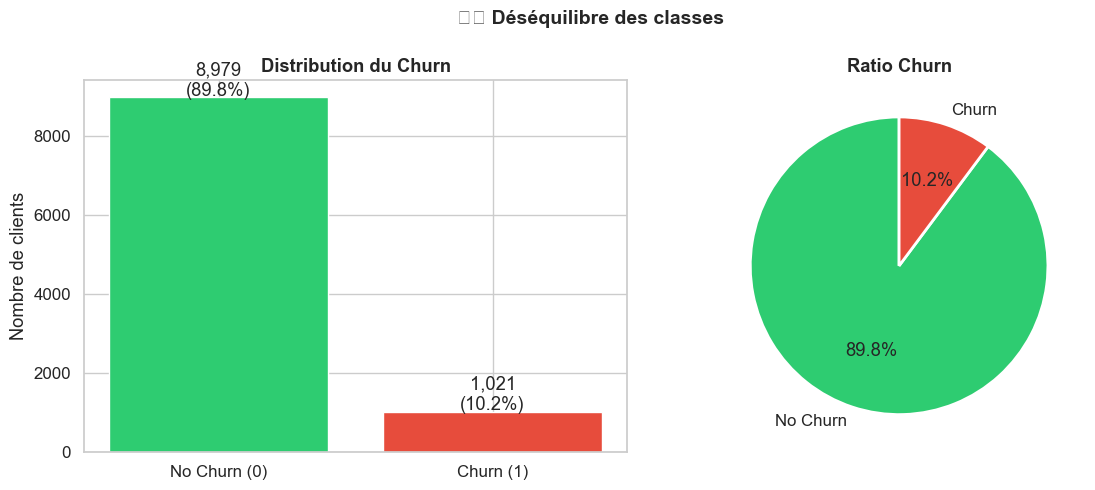


Ratio déséquilibre : 8.8:1 → classe minoritaire = 10.2%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
counts = df["churn"].value_counts()
axes[0].bar(["No Churn (0)", "Churn (1)"], counts.values,
            color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Distribution du Churn", fontweight="bold")
axes[0].set_ylabel("Nombre de clients")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center")

# Pie chart
axes[1].pie(counts.values, labels=["No Churn", "Churn"],
            colors=["#2ecc71", "#e74c3c"], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Ratio Churn", fontweight="bold")

plt.suptitle("⚠️ Déséquilibre des classes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

ratio = counts[0] / counts[1]
print(f"\nRatio déséquilibre : {ratio:.1f}:1 → classe minoritaire = {counts[1]/len(df)*100:.1f}%")

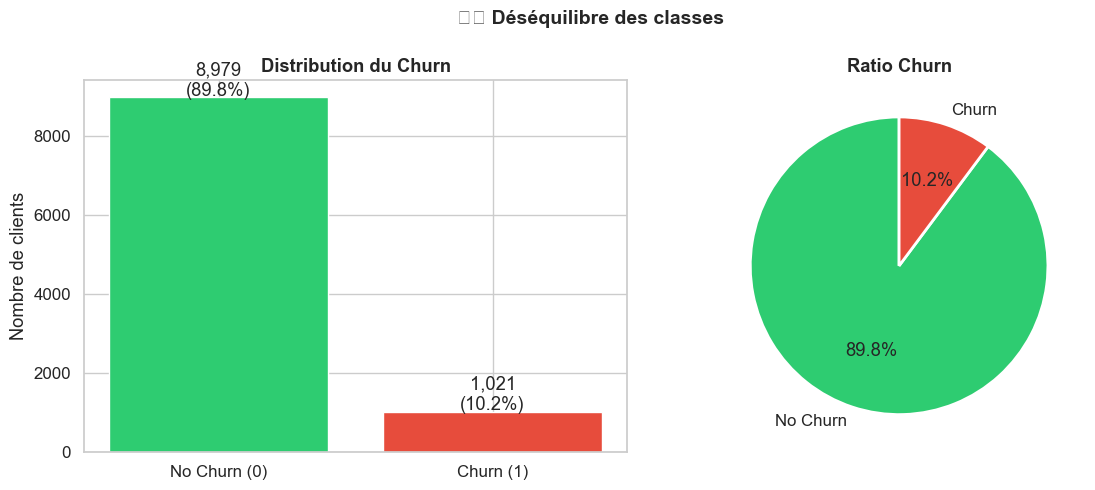


Ratio déséquilibre : 8.8:1 → classe minoritaire = 10.2%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
counts = df["churn"].value_counts()
axes[0].bar(["No Churn (0)", "Churn (1)"], counts.values,
            color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Distribution du Churn", fontweight="bold")
axes[0].set_ylabel("Nombre de clients")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center")

# Pie chart
axes[1].pie(counts.values, labels=["No Churn", "Churn"],
            colors=["#2ecc71", "#e74c3c"], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Ratio Churn", fontweight="bold")

plt.suptitle("⚠️ Déséquilibre des classes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

ratio = counts[0] / counts[1]
print(f"\nRatio déséquilibre : {ratio:.1f}:1 → classe minoritaire = {counts[1]/len(df)*100:.1f}%")

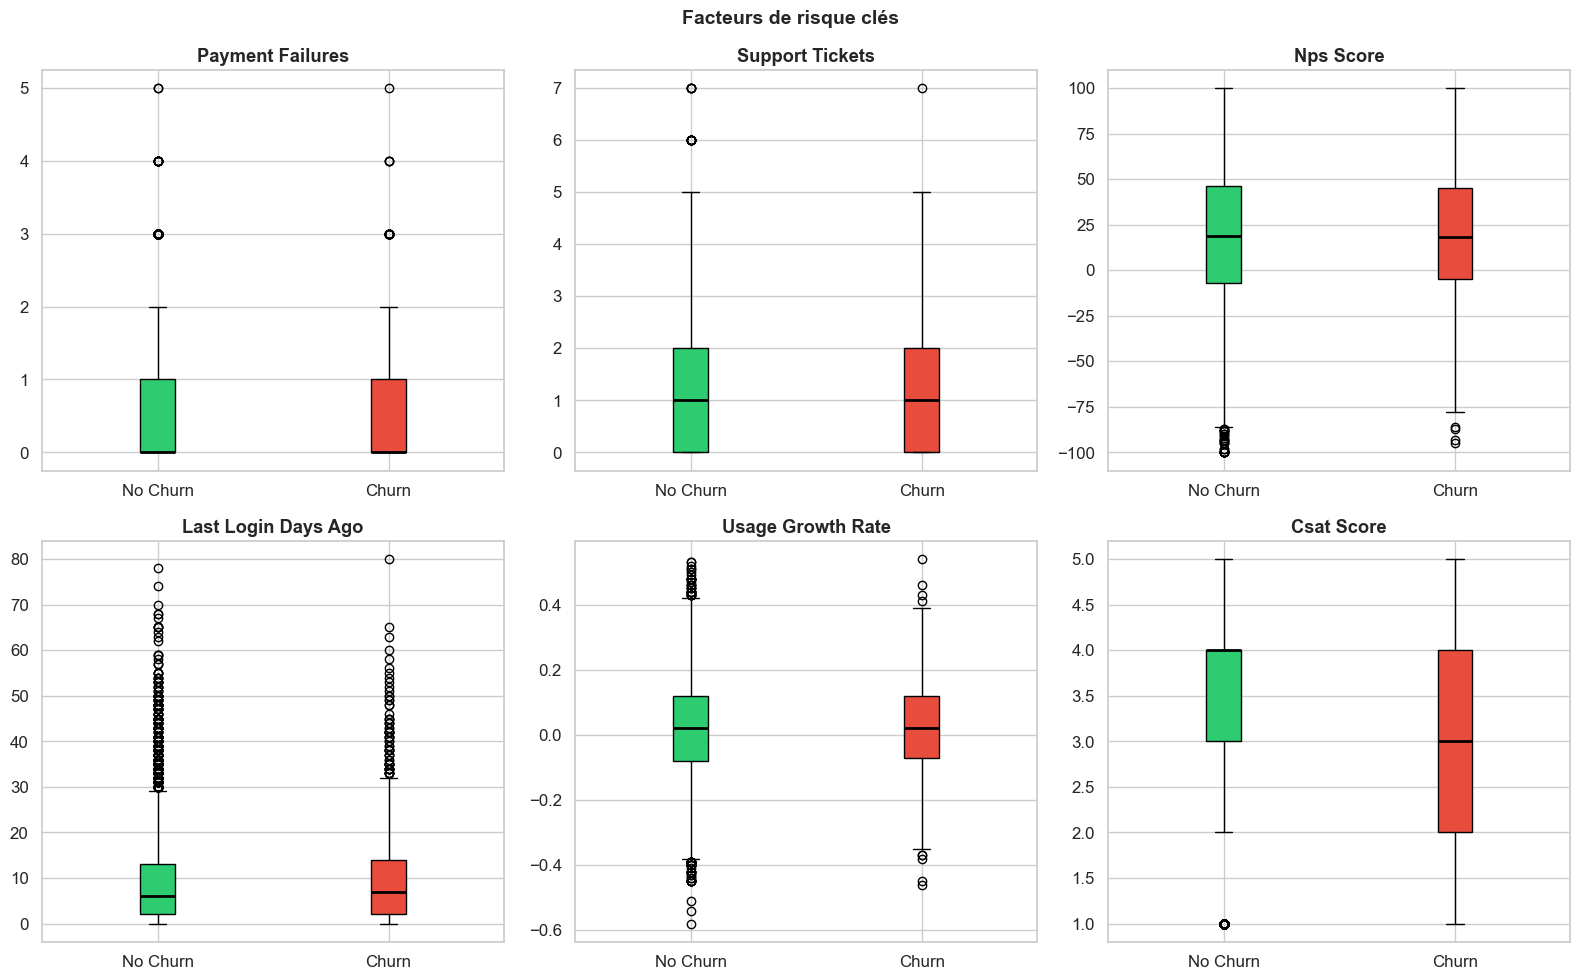

In [10]:
risk_cols = ["payment_failures", "support_tickets", "nps_score",
             "last_login_days_ago", "usage_growth_rate", "csat_score"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(risk_cols):
    data_0 = df[df["churn"] == 0][col]
    data_1 = df[df["churn"] == 1][col]
    bp = axes[i].boxplot([data_0, data_1], labels=["No Churn", "Churn"],
                          patch_artist=True,
                          medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#2ecc71")
    bp["boxes"][1].set_facecolor("#e74c3c")
    axes[i].set_title(col.replace("_", " ").title(), fontweight="bold")

plt.suptitle("Facteurs de risque clés", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/03_risk_factors.png", dpi=150, bbox_inches="tight")
plt.show()

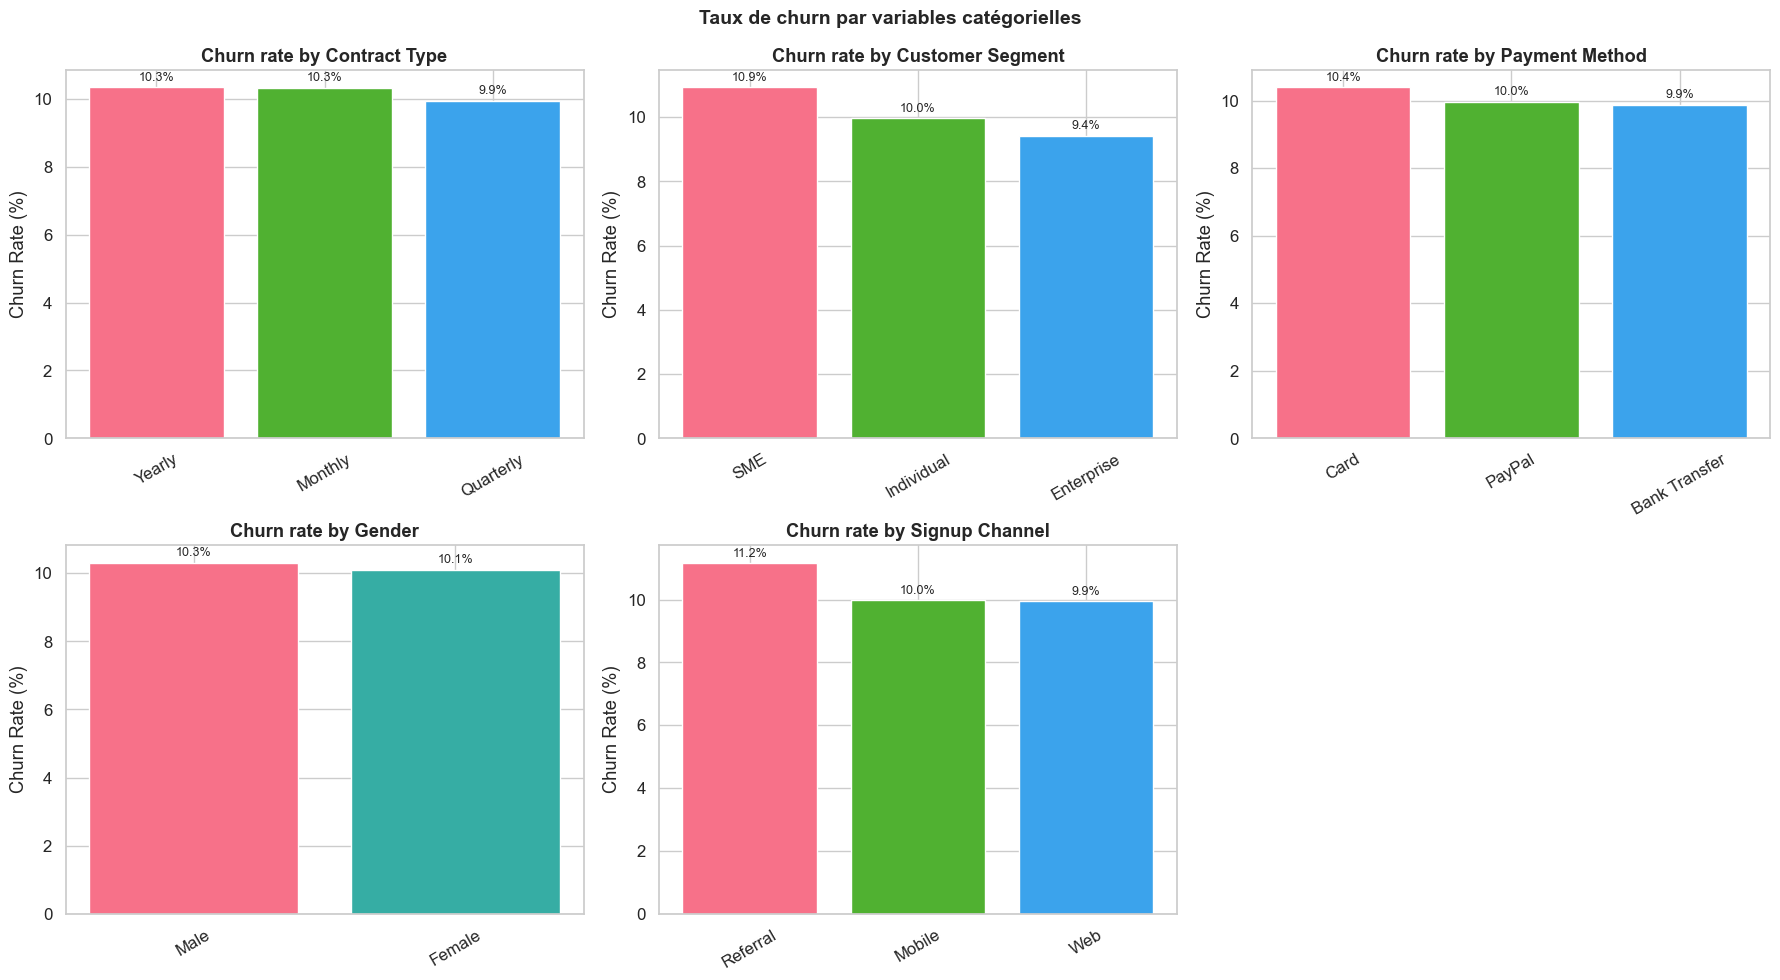

In [11]:
cat_cols = ["contract_type", "customer_segment", "payment_method",
            "gender", "signup_channel"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)["churn"].mean().sort_values(ascending=False)
    axes[i].bar(churn_rate.index, churn_rate.values * 100,
                color=sns.color_palette("husl", len(churn_rate)))
    axes[i].set_title(f"Churn rate by {col.replace('_',' ').title()}", fontweight="bold")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].tick_params(axis="x", rotation=30)
    for j, v in enumerate(churn_rate.values):
        axes[i].text(j, v * 100 + 0.2, f"{v*100:.1f}%", ha="center", fontsize=9)

axes[-1].axis("off")
plt.suptitle("Taux de churn par variables catégorielles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/04_categorical_churn.png", dpi=150, bbox_inches="tight")
plt.show()

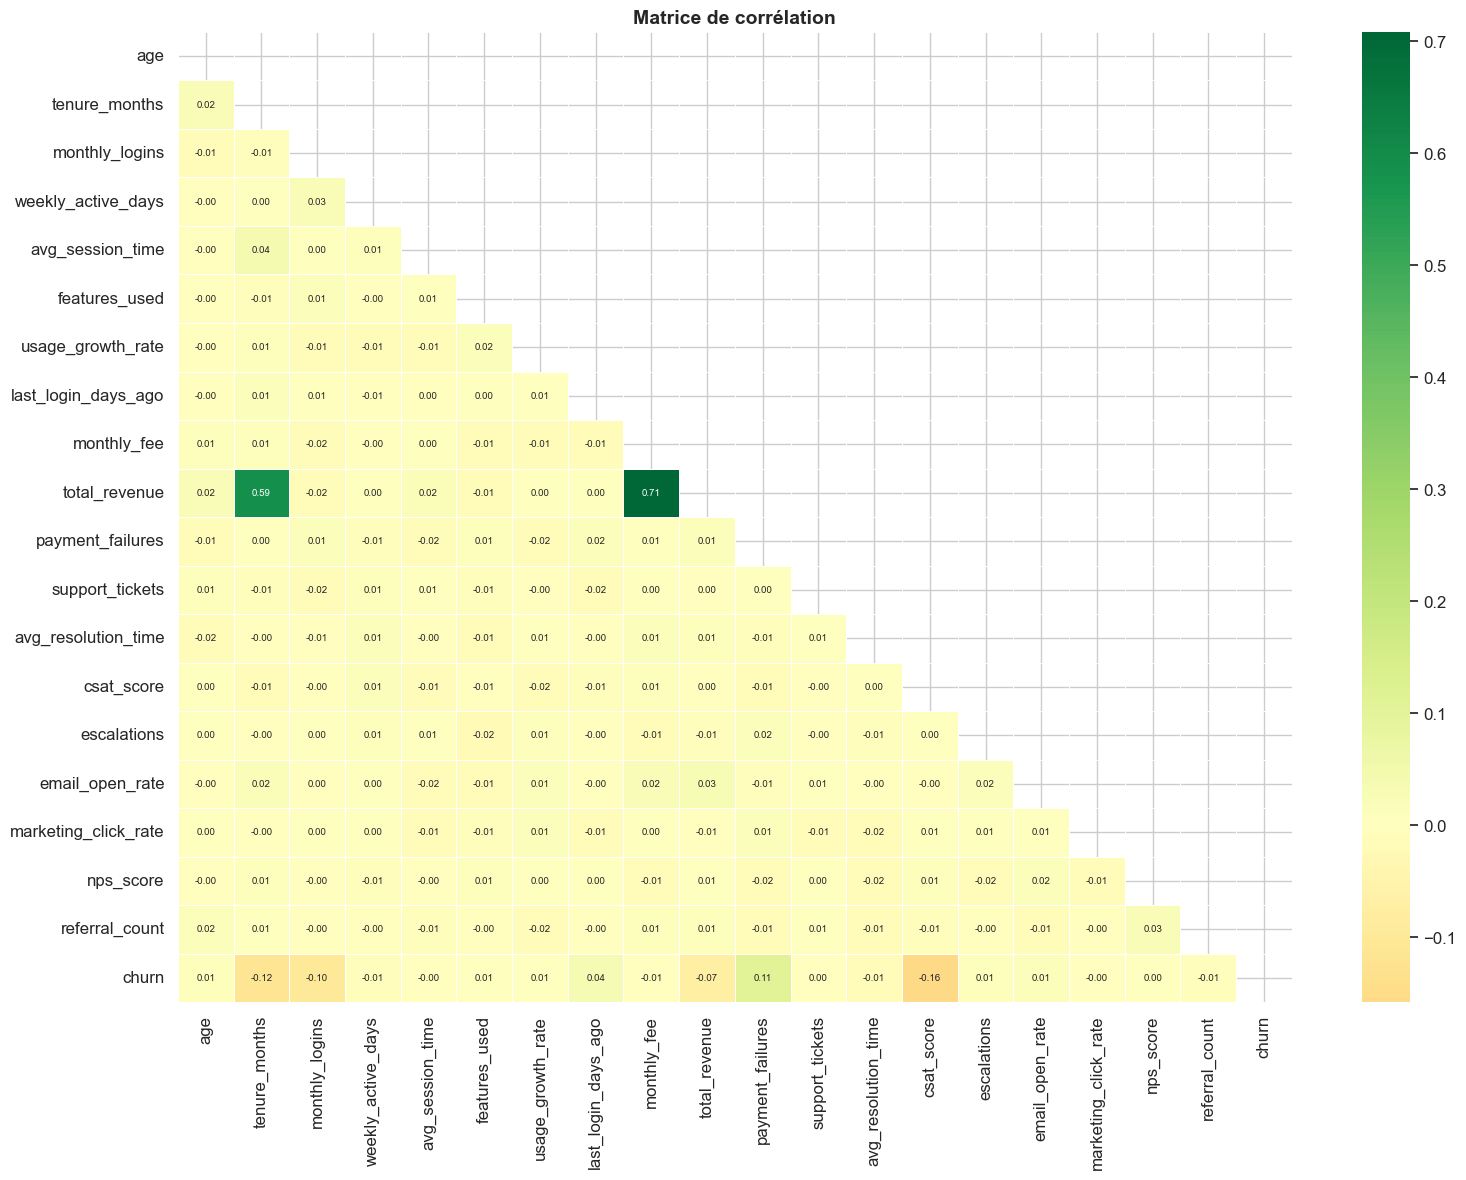

In [12]:
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5, annot_kws={"size": 7})
ax.set_title("Matrice de corrélation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/05_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

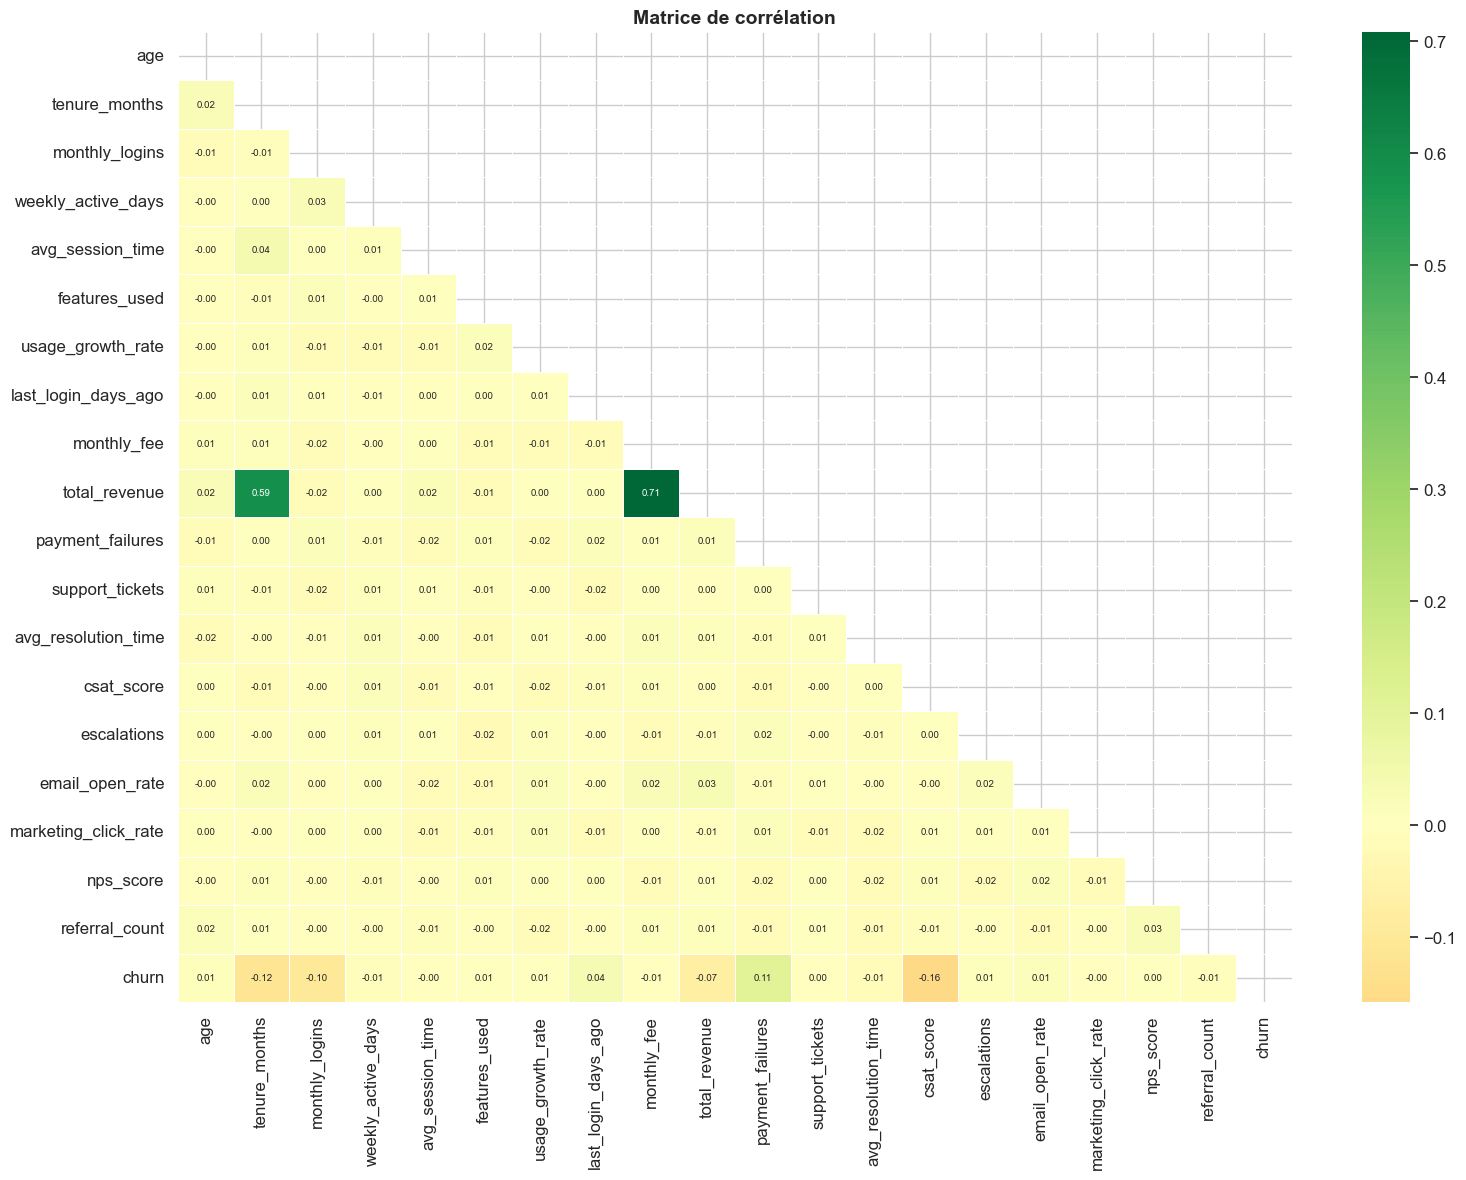

In [13]:
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5, annot_kws={"size": 7})
ax.set_title("Matrice de corrélation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/05_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()